**Diabetes Preiction Machine Learning Project**

M.Sc. in CSE. Professional Program

Name:

ID:

Bacth: 16

Department: CSE



**Diabetes Dataset import**

In [8]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd

file_path = '/content/drive/MyDrive/Adnan bcs/diabetes_prediction_dataset.csv'

try:
    # Load the dataset (assuming it's a CSV file)
    df = pd.read_csv(file_path)

    # View the first 5 rows of the dataset
    print("Dataset loaded successfully. Here are the first 5 rows:")
    print(df.head())


except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully. Here are the first 5 rows:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [10]:
print("\n--- Dataset Information ---")
df.info()


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [11]:
print("\n--- Descriptive Statistics ---")
df.describe()


--- Descriptive Statistics ---


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


The `df.info()` output gives us a summary of the DataFrame, including the number of entries, columns, non-null values, and data types. This helps us identify if there are any missing values or if data types need to be converted. The `df.describe()` output provides descriptive statistics for numerical columns, such as mean, standard deviation, min, max, and quartiles, which are useful for understanding the distribution and spread of the data.

In [12]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


The isnull().sum()  method helps us identify the count of missing values in each column. This is crucial for data preprocessing, as missing values often need to be handled (e.g., by imputation or removal) before building a machine learning model.

**Visualize**


--- Distribution of Diabetes Status ---


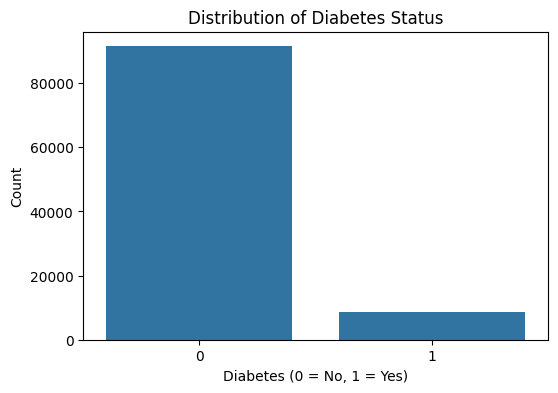

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Distribution of Diabetes Status ---")
plt.figure(figsize=(6, 4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes Status')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

This count plot visualizes the distribution of the target variable `diabetes`. It shows the number of individuals with and without diabetes in the dataset. This helps in understanding the class balance, which is important for model training (e.g., identifying imbalanced datasets).

**Preprocessing**

In [15]:
# Identify categorical columns for one-hot encoding
categorical_cols = ['gender', 'smoking_history']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after One-Hot Encoding:")
print(df_encoded.head())

# Identify numerical columns for scaling (excluding binary and target column)
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("\nDataFrame after Feature Scaling:")
print(df_encoded.head())






DataFrame after One-Hot Encoding:
    age  hypertension  heart_disease    bmi  HbA1c_level  blood_glucose_level  \
0  80.0             0              1  25.19          6.6                  140   
1  54.0             0              0  27.32          6.6                   80   
2  28.0             0              0  27.32          5.7                  158   
3  36.0             0              0  23.45          5.0                  155   
4  76.0             1              1  20.14          4.8                  155   

   diabetes  gender_Male  gender_Other  smoking_history_current  \
0         0        False         False                    False   
1         0        False         False                    False   
2         0         True         False                    False   
3         0        False         False                     True   
4         0         True         False                     True   

   smoking_history_ever  smoking_history_former  smoking_history_never  \
0 

**Preparing Features**

In [16]:
# Prepare features (X) and target (y)
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

**Splitting the data**

Train 80%

Test 20%

In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Using a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (80000, 13)
Shape of X_test: (20000, 13)
Shape of y_train: (80000,)
Shape of y_test: (20000,)


**Regression Model Building and Training**

In [18]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter to a higher value for convergence if needed
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

print("Logistic Regression model initialized.")

Logistic Regression model initialized.


In [19]:
# Train the model using the training data
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


**Model Evaluation**

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Accuracy: 0.9605
Precision: 0.8593
Recall: 0.6394
F1-Score: 0.7332
ROC AUC Score: 0.9625

--- Confusion Matrix ---
[[18122   178]
 [  613  1087]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



**Random Forest Model Building and Training**

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# Using a random state for reproducibility
# n_estimators can be adjusted for performance vs. computational cost
model_rf = RandomForestClassifier(random_state=42, n_estimators=100)

print("Random Forest model initialized.")

# Train the model using the training data
model_rf.fit(X_train, y_train)

print("Random Forest model training completed.")

Random Forest model initialized.
Random Forest model training completed.


**Random Forest Model Evaluation**

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set with Random Forest
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")

print("\n--- Random Forest Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9704
Random Forest Precision: 0.9489
Random Forest Recall: 0.6888
Random Forest F1-Score: 0.7982
Random Forest ROC AUC Score: 0.9613

--- Random Forest Confusion Matrix ---
[[18237    63]
 [  529  1171]]

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



**Hyperparameter Tuning for Random Forest Model**

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],  # Number of features to consider at each split
    'max_depth': [10, 20, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]  # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
# Using f1_weighted for scoring due to potential class imbalance
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='f1_weighted', cv=3, n_jobs=-1, verbose=2)

print("Starting Grid Search for Random Forest hyperparameters...")

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Grid Search completed.")

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best F1-weighted score: {grid_search.best_score_:.4f}")

Starting Grid Search for Random Forest hyperparameters...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Grid Search completed.

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best F1-weighted score: 0.9694


**Re-evaluating Random Forest Model with Tuned Hyperparameters**

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Get the best model from Grid Search
best_rf_model = grid_search.best_estimator_

print("Random Forest model with best hyperparameters initialized.")

# Make predictions on the test set with the best Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)
y_pred_proba_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class

# Calculate evaluation metrics for the tuned Random Forest
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
roc_auc_tuned_rf = roc_auc_score(y_test, y_pred_proba_tuned_rf)

print(f"Tuned Random Forest Accuracy: {accuracy_tuned_rf:.4f}")
print(f"Tuned Random Forest Precision: {precision_tuned_rf:.4f}")
print(f"Tuned Random Forest Recall: {recall_tuned_rf:.4f}")
print(f"Tuned Random Forest F1-Score: {f1_tuned_rf:.4f}")
print(f"Tuned Random Forest ROC AUC Score: {roc_auc_tuned_rf:.4f}")

print("\n--- Tuned Random Forest Confusion Matrix ---")
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
print(cm_tuned_rf)

print("\n--- Tuned Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_tuned_rf))

Random Forest model with best hyperparameters initialized.
Tuned Random Forest Accuracy: 0.9720
Tuned Random Forest Precision: 0.9831
Tuned Random Forest Recall: 0.6829
Tuned Random Forest F1-Score: 0.8060
Tuned Random Forest ROC AUC Score: 0.9731

--- Tuned Random Forest Confusion Matrix ---
[[18280    20]
 [  539  1161]]

--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.98      0.68      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.98      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000



**ROC Curve Comparison**

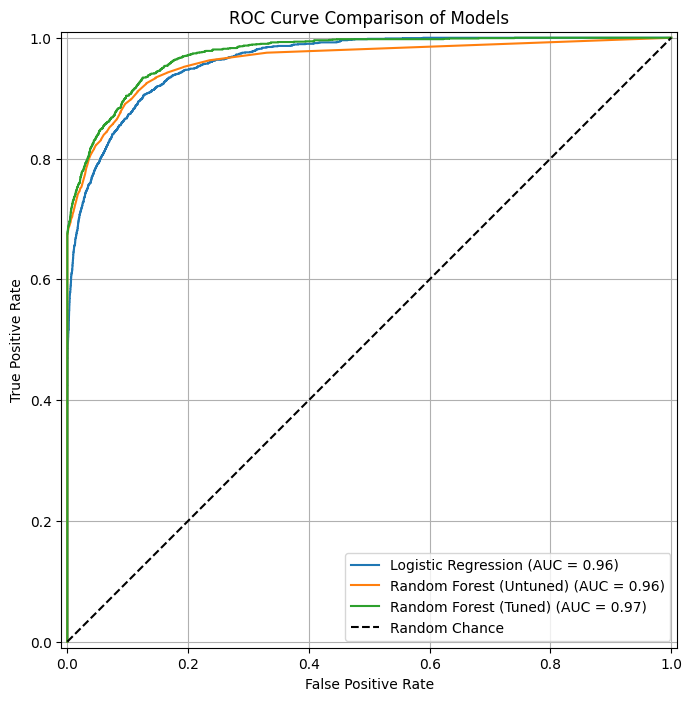

In [27]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression
RocCurveDisplay.from_predictions(y_test, y_pred_proba, name='Logistic Regression', ax=plt.gca())

# Plot ROC curve for Random Forest (untuned)
RocCurveDisplay.from_predictions(y_test, y_pred_proba_rf, name='Random Forest (Untuned)', ax=plt.gca())

# Plot ROC curve for Tuned Random Forest
RocCurveDisplay.from_predictions(y_test, y_pred_proba_tuned_rf, name='Random Forest (Tuned)', ax=plt.gca())

plt.title('ROC Curve Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance') # Add a diagonal random chance line
plt.legend()
plt.grid(True)
plt.show()

**Model Performance Summary**

In [28]:
import pandas as pd

# Create a dictionary to store the metrics for each model
metrics = {
    'Model': ['Logistic Regression', 'Random Forest (Untuned)', 'Random Forest (Tuned)'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_tuned_rf],
    'Precision': [precision, precision_rf, precision_tuned_rf],
    'Recall': [recall, recall_rf, recall_tuned_rf],
    'F1-Score': [f1, f1_rf, f1_tuned_rf],
    'ROC AUC Score': [roc_auc, roc_auc_rf, roc_auc_tuned_rf]
}

# Create a DataFrame from the metrics dictionary
metrics_df = pd.DataFrame(metrics)

# Display the summary table
print("\n--- Model Performance Summary ---")
display(metrics_df.round(4))


--- Model Performance Summary ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,0.9604,0.8593,0.6394,0.7332,0.9625
1,Random Forest (Untuned),0.9704,0.9489,0.6888,0.7982,0.9613
2,Random Forest (Tuned),0.9720,0.9831,0.6829,0.8060,0.9731


**Download models**

In [29]:
import joblib
import os

# Define the directory to save the models in Google Drive
model_save_dir = '/content/drive/MyDrive/Colab_Models/'

# Create the directory if it doesn't exist
os.makedirs(model_save_dir, exist_ok=True)

# Save the Logistic Regression model
logistic_regression_model_path = os.path.join(model_save_dir, 'logistic_regression_model.joblib')
joblib.dump(model, logistic_regression_model_path)
print(f"Logistic Regression model saved to: {logistic_regression_model_path}")

# Save the Tuned Random Forest model
tuned_random_forest_model_path = os.path.join(model_save_dir, 'tuned_random_forest_model.joblib')
joblib.dump(best_rf_model, tuned_random_forest_model_path)
print(f"Tuned Random Forest model saved to: {tuned_random_forest_model_path}")

print("Models saved successfully to your Google Drive. You can find them in the 'Colab_Models' folder.")

Logistic Regression model saved to: /content/drive/MyDrive/Colab_Models/logistic_regression_model.joblib
Tuned Random Forest model saved to: /content/drive/MyDrive/Colab_Models/tuned_random_forest_model.joblib
Models saved successfully to your Google Drive. You can find them in the 'Colab_Models' folder.
